In [1]:
# import all the things
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# setting plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [3]:
# loading the dataset
DATA_PATH = Path("data") / "manufacturing_defect_dataset.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

if df.empty:
    raise ValueError("Dataset loaded but contains no rows")

df.head()

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
0,202,13175.403783,86.648534,1,3.121492,63.463494,9,0.052343,8.630515,0.081322,85.042379,0,2419.616785,0.468947,5.551639,236.439301,1
1,535,19770.046093,86.310664,4,0.819531,83.697818,20,4.908328,9.296598,0.038486,99.657443,7,3915.566713,0.119485,9.080754,353.957631,1
2,960,19060.820997,82.132472,0,4.514504,90.350550,1,2.464923,5.097486,0.002887,92.819264,2,3392.385362,0.496392,6.562827,396.189402,1
3,370,5647.606037,87.335966,5,0.638524,67.628690,8,4.692476,3.577616,0.055331,96.887013,8,4652.400275,0.183125,8.097496,164.135870,1
4,206,7472.222236,81.989893,3,3.867784,82.728334,9,2.746726,6.851709,0.068047,88.315554,7,1581.630332,0.263507,6.406154,365.708964,1


In [4]:
# structure check
print("Shape:", df.shape)
print("\nColumns:")
for col in df.columns:
    print(" -", col)

Shape: (3240, 17)

Columns:
 - ProductionVolume
 - ProductionCost
 - SupplierQuality
 - DeliveryDelay
 - DefectRate
 - QualityScore
 - MaintenanceHours
 - DowntimePercentage
 - InventoryTurnover
 - StockoutRate
 - WorkerProductivity
 - SafetyIncidents
 - EnergyConsumption
 - EnergyEfficiency
 - AdditiveProcessTime
 - AdditiveMaterialCost
 - DefectStatus


In [6]:
# data types and missing info check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductionVolume      3240 non-null   int64  
 1   ProductionCost        3240 non-null   float64
 2   SupplierQuality       3240 non-null   float64
 3   DeliveryDelay         3240 non-null   int64  
 4   DefectRate            3240 non-null   float64
 5   QualityScore          3240 non-null   float64
 6   MaintenanceHours      3240 non-null   int64  
 7   DowntimePercentage    3240 non-null   float64
 8   InventoryTurnover     3240 non-null   float64
 9   StockoutRate          3240 non-null   float64
 10  WorkerProductivity    3240 non-null   float64
 11  SafetyIncidents       3240 non-null   int64  
 12  EnergyConsumption     3240 non-null   float64
 13  EnergyEfficiency      3240 non-null   float64
 14  AdditiveProcessTime   3240 non-null   float64
 15  AdditiveMaterialCost  3240 non-n

In [7]:
df.isnull().sum().sort_values

<bound method Series.sort_values of ProductionVolume        0
ProductionCost          0
SupplierQuality         0
DeliveryDelay           0
DefectRate              0
QualityScore            0
MaintenanceHours        0
DowntimePercentage      0
InventoryTurnover       0
StockoutRate            0
WorkerProductivity      0
SafetyIncidents         0
EnergyConsumption       0
EnergyEfficiency        0
AdditiveProcessTime     0
AdditiveMaterialCost    0
DefectStatus            0
dtype: int64>

C:\Users\morganmic\PycharmProjects\Manufacturing_Defects\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


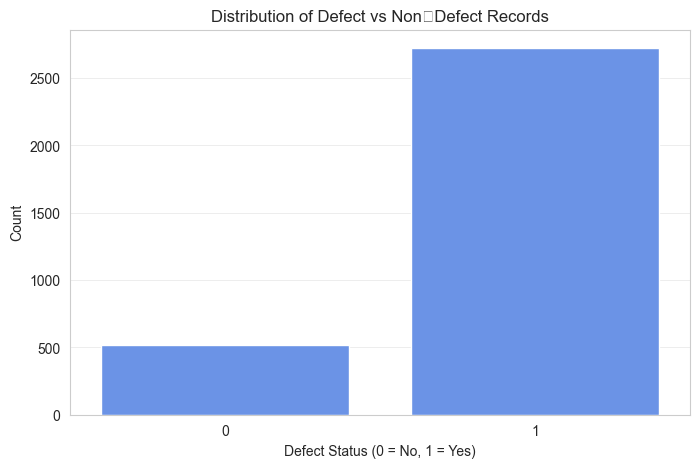

In [8]:
# defect vs non-defect distribution visualization
plt.figure()
sns.countplot(x="DefectStatus", data=df)
plt.title("Distribution of Defect vs Non‑Defect Records")
plt.xlabel("Defect Status (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

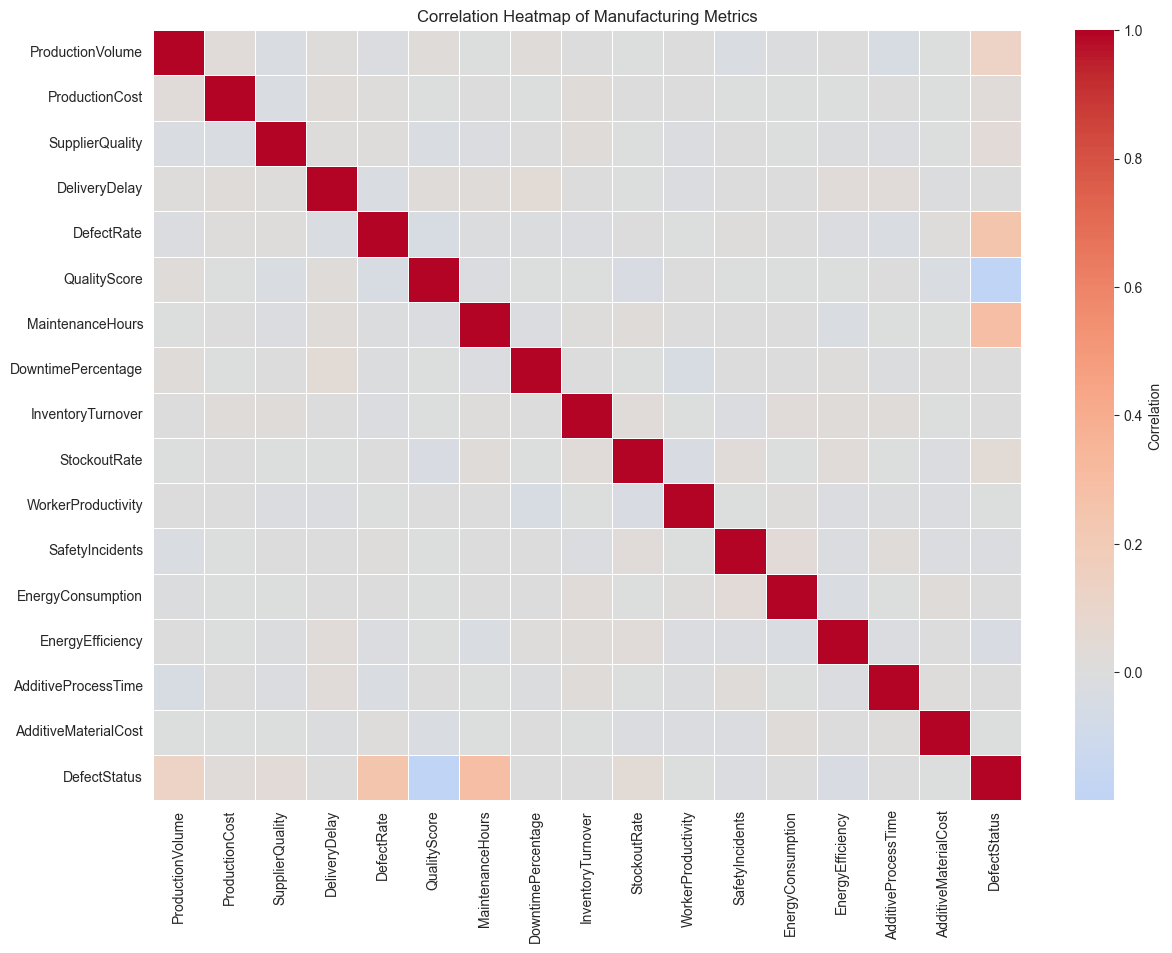

In [9]:
# correlation heatmap
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    cbar_kws={"label": "Correlation"}
)
plt.title("Correlation Heatmap of Manufacturing Metrics")
plt.show()

In [11]:
# making the heatmap actionable by putting numbers to the correlations.
corr_target = corr["DefectStatus"].sort_values(ascending=False)
corr_target

DefectStatus            1.000000
MaintenanceHours        0.297107
DefectRate              0.245746
ProductionVolume        0.128973
StockoutRate            0.040574
SupplierQuality         0.038184
ProductionCost          0.026720
InventoryTurnover       0.006733
AdditiveProcessTime     0.005619
DeliveryDelay           0.005425
EnergyConsumption       0.005039
DowntimePercentage      0.004128
AdditiveMaterialCost   -0.000953
WorkerProductivity     -0.005224
SafetyIncidents        -0.016039
EnergyEfficiency       -0.035031
QualityScore           -0.199219
Name: DefectStatus, dtype: float64

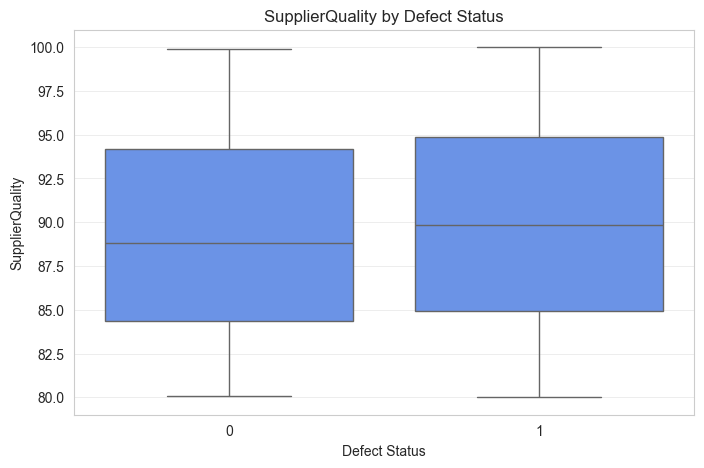

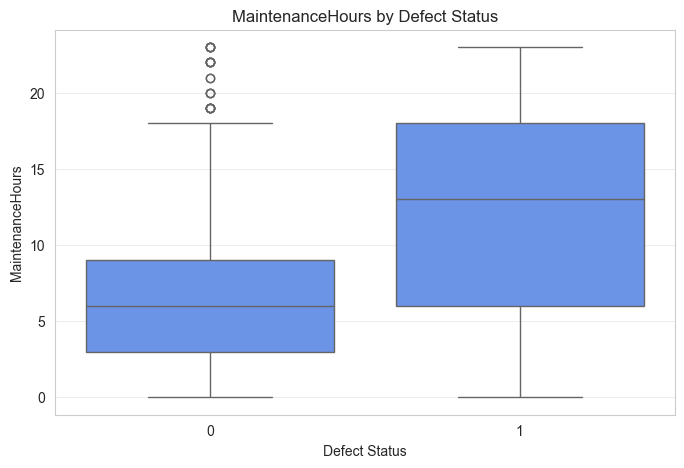

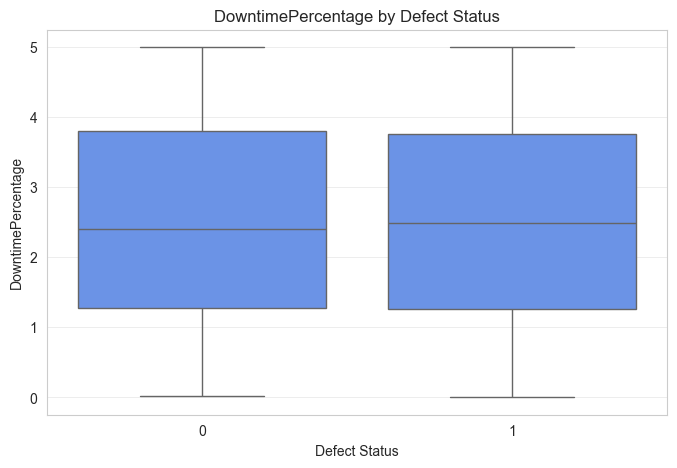

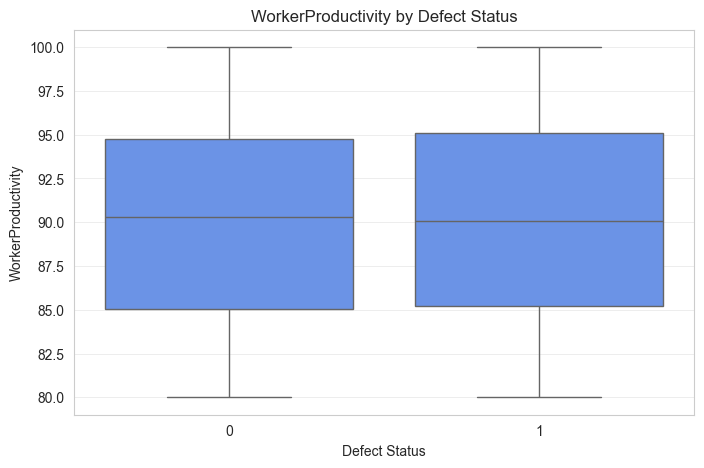

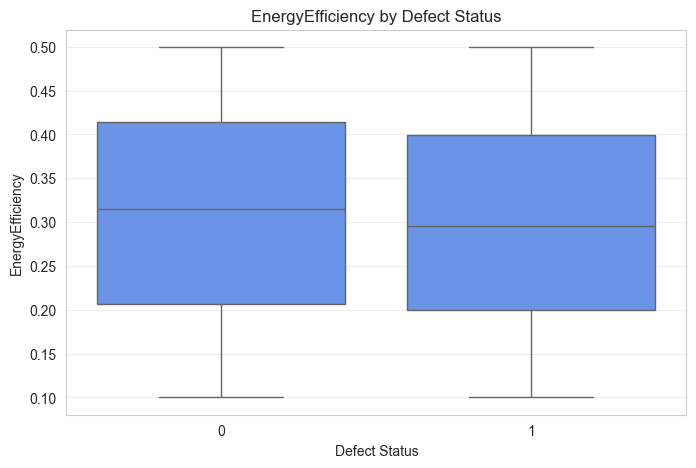

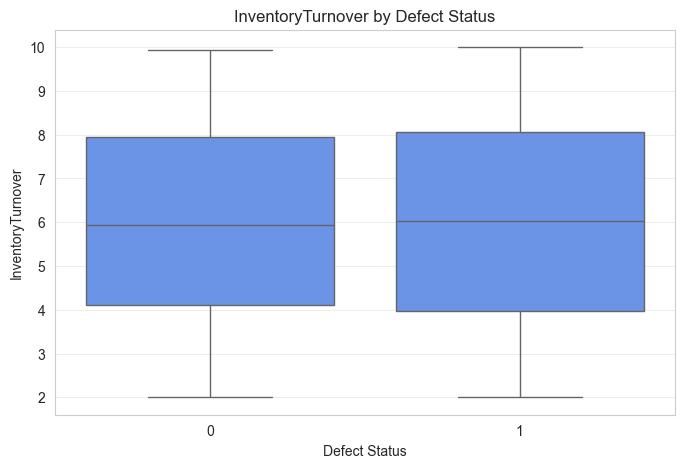

In [12]:
# key features by defect status
features = [
    "SupplierQuality",
    "MaintenanceHours",
    "DowntimePercentage",
    "WorkerProductivity",
    "EnergyEfficiency",
    "InventoryTurnover"
]

for col in features:
    if col in df.columns:
        plt.figure()
        sns.boxplot(x="DefectStatus", y=col, data=df)
        plt.title(f"{col} by Defect Status")
        plt.xlabel("Defect Status")
        plt.show()


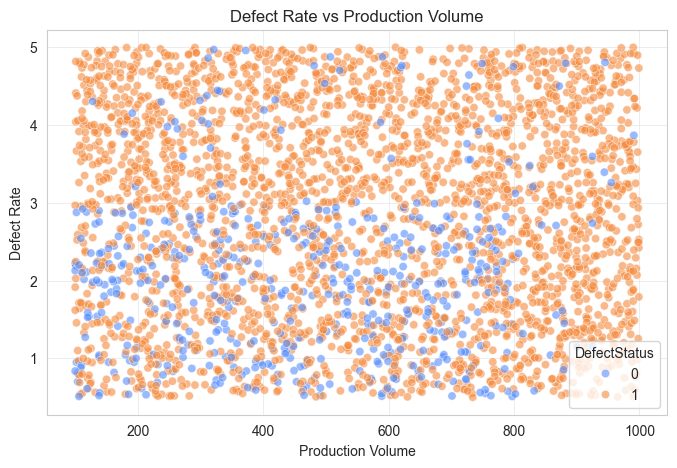

In [13]:
# scatterplot of defect rate vs production
plt.figure()
sns.scatterplot(
    x="ProductionVolume",
    y="DefectRate",
    hue="DefectStatus",
    data=df,
    alpha=0.6
)
plt.title("Defect Rate vs Production Volume")
plt.xlabel("Production Volume")
plt.ylabel("Defect Rate")
plt.show()

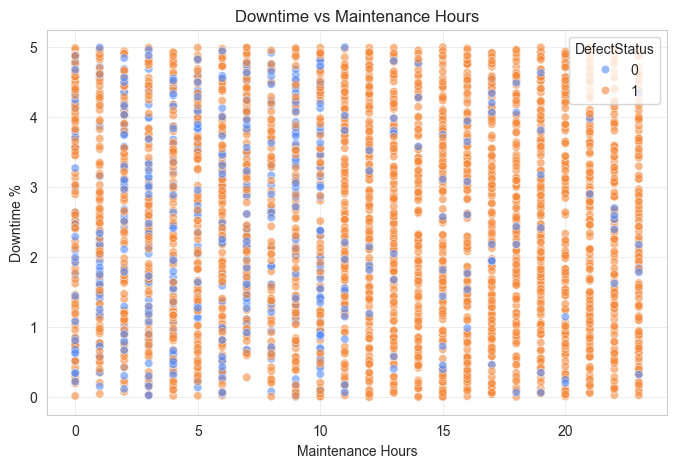

In [14]:
# downtime vs maintenance
plt.figure()
sns.scatterplot(
    x="MaintenanceHours",
    y="DowntimePercentage",
    hue="DefectStatus",
    data=df,
    alpha=0.6
)
plt.title("Downtime vs Maintenance Hours")
plt.xlabel("Maintenance Hours")
plt.ylabel("Downtime %")
plt.show()

### Key Observations

- Defects appear associated with:
  - Increased Downtime Percentage
  - Lower Supplier Quality
  - Reduced Worker Productivity
- Some energy and additive manufacturing variables show weak correlation
- Defective units tend to cluster in operational inefficiency regions

These visual patterns suggest opportunities for defect reduction through:
- Supplier controls
- Maintenance strategy optimization
- Workforce productivity improvements